# DeepCFD Training Notebook

This notebook trains a U-Net model to predict CFD simulations from geometric inputs.

**Dataset**: 
- Input: 3 channels (SDF obstacle, flow region, SDF surfaces)
- Output: 3 channels (Ux velocity, Uy velocity, pressure)
- Samples: 981, Grid: 172x79

## Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import pickle
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Define UNet Architecture

In [2]:
class ConvBlock(nn.Module):
    """Simple Conv -> ReLU block"""
    def __init__(self, in_channels, out_channels, kernel_size=5):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding)
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        return self.relu(self.conv(x))


class EncoderBlock(nn.Module):
    """Encoder: Conv -> Conv -> MaxPool (returns pooled output and skip connection)"""
    def __init__(self, in_channels, out_channels, kernel_size=5):
        super().__init__()
        self.conv1 = ConvBlock(in_channels, out_channels, kernel_size)
        self.conv2 = ConvBlock(out_channels, out_channels, kernel_size)
        self.pool = nn.MaxPool2d(2, 2, return_indices=True)
    
    def forward(self, x):
        # Two convolutions
        x = self.conv1(x)
        x = self.conv2(x)
        # Store size and features for skip connection
        size = x.size()
        # Pool for next stage
        x_pooled, indices = self.pool(x)
        return x_pooled, x, indices, size


class DecoderBlock(nn.Module):
    """Decoder: Unpool -> Concat with skip -> Conv -> Conv"""
    def __init__(self, in_channels, out_channels, kernel_size=5):
        super().__init__()
        self.unpool = nn.MaxUnpool2d(2, 2)
        # After concat: in_channels (from previous) + in_channels (from skip) = 2*in_channels
        self.conv1 = ConvBlock(in_channels * 2, in_channels, kernel_size)
        self.conv2 = ConvBlock(in_channels, out_channels, kernel_size)
    
    def forward(self, x, skip, indices, size):
        # Unpool to original size
        x = self.unpool(x, indices, output_size=size)
        # Concatenate with skip connection
        x = torch.cat([skip, x], dim=1)
        # Two convolutions
        x = self.conv1(x)
        x = self.conv2(x)
        return x


class UNetEx(nn.Module):
    """
    U-Net with separate decoder for each output channel.
    Architecture: 4 encoder stages -> bottleneck -> 3 separate decoders (one per output)
    """
    def __init__(self, in_channels=3, out_channels=3, kernel_size=5, filters=[8, 16, 32, 32]):
        super().__init__()
        
        # Encoder path (4 stages)
        self.encoder1 = EncoderBlock(in_channels, filters[0], kernel_size)
        self.encoder2 = EncoderBlock(filters[0], filters[1], kernel_size)
        self.encoder3 = EncoderBlock(filters[1], filters[2], kernel_size)
        self.encoder4 = EncoderBlock(filters[2], filters[3], kernel_size)
        
        # Bottleneck
        self.bottleneck = nn.Sequential(
            ConvBlock(filters[3], filters[3], kernel_size),
            ConvBlock(filters[3], filters[3], kernel_size)
        )
        
        # Create 3 separate decoders (one for Ux, one for Uy, one for pressure)
        self.decoders = nn.ModuleList([
            nn.ModuleList([
                DecoderBlock(filters[3], filters[2], kernel_size),
                DecoderBlock(filters[2], filters[1], kernel_size),
                DecoderBlock(filters[1], filters[0], kernel_size),
                DecoderBlock(filters[0], filters[0], kernel_size),
                nn.Conv2d(filters[0], 1, kernel_size=1)  # Final 1x1 conv to 1 channel
            ])
            for _ in range(out_channels)  # Create 3 identical decoder paths
        ])
    
    def forward(self, x):
        # Encoder path - downsample and collect skip connections
        x1, skip1, idx1, size1 = self.encoder1(x)    # 172x79 -> 86x39, features: 8
        x2, skip2, idx2, size2 = self.encoder2(x1)   # 86x39 -> 43x19, features: 16
        x3, skip3, idx3, size3 = self.encoder3(x2)   # 43x19 -> 21x9, features: 32
        x4, skip4, idx4, size4 = self.encoder4(x3)   # 21x9 -> 10x4, features: 32
        
        # Bottleneck
        x = self.bottleneck(x4)
        
        # Decode separately for each output channel
        outputs = []
        for decoder in self.decoders:
            # Start from bottleneck
            d = x
            # Upsample through decoder stages with skip connections
            d = decoder[0](d, skip4, idx4, size4)  # 10x4 -> 21x9
            d = decoder[1](d, skip3, idx3, size3)  # 21x9 -> 43x19
            d = decoder[2](d, skip2, idx2, size2)  # 43x19 -> 86x39
            d = decoder[3](d, skip1, idx1, size1)  # 86x39 -> 172x79
            d = decoder[4](d)  # Final 1x1 conv to single channel
            outputs.append(d)
        
        # Concatenate all 3 output channels (Ux, Uy, p)
        return torch.cat(outputs, dim=1)

print("UNet architecture defined!")

UNet architecture defined!


## Load Dataset

In [4]:
# Load data
x = pickle.load(open('./dataset/dataX.pkl', 'rb'))
y = pickle.load(open('./dataset/dataY.pkl', 'rb'))

print(f"Input shape: {x.shape}")
print(f"Output shape: {y.shape}")
print(f"Samples: {x.shape[0]}, Channels: {x.shape[1]}, Grid: {x.shape[2]}x{x.shape[3]}")

# Convert to tensors
x = torch.FloatTensor(x)
y = torch.FloatTensor(y)

# Compute channel weights for normalization
batch, nx, ny = y.shape[0], y.shape[2], y.shape[3]
channel_weights = torch.sqrt(
    torch.mean(y.permute(0, 2, 3, 1).reshape((batch * nx * ny, 3)) ** 2, dim=0)
).view(1, -1, 1, 1).to(device)

print(f"\nChannel weights (Ux, Uy, p): {channel_weights.cpu().numpy().flatten()}")

Input shape: (981, 3, 172, 79)
Output shape: (981, 3, 172, 79)
Samples: 981, Channels: 3, Grid: 172x79

Channel weights (Ux, Uy, p): [0.11532926 0.01745924 0.01346998]


## Visualize Sample Data

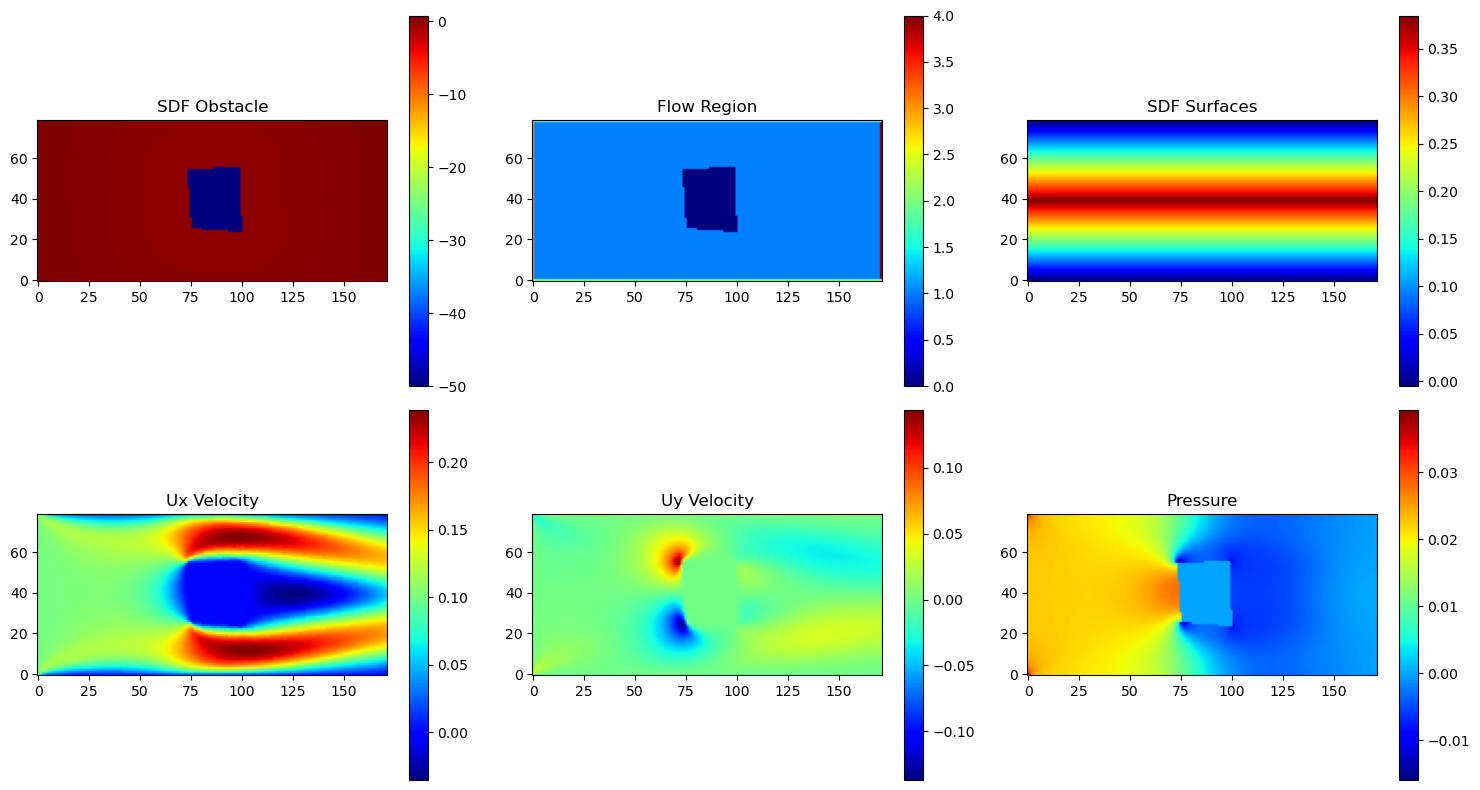

In [5]:
def plot_sample(x_data, y_data, idx=0):
    """Visualize input geometry and output fields"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    # Input channels
    titles_x = ['SDF Obstacle', 'Flow Region', 'SDF Surfaces']
    for i in range(3):
        im = axes[0, i].imshow(x_data[idx, i].T, cmap='jet', origin='lower')
        axes[0, i].set_title(titles_x[i])
        plt.colorbar(im, ax=axes[0, i])
    
    # Output channels
    titles_y = ['Ux Velocity', 'Uy Velocity', 'Pressure']
    for i in range(3):
        im = axes[1, i].imshow(y_data[idx, i].T, cmap='jet', origin='lower')
        axes[1, i].set_title(titles_y[i])
        plt.colorbar(im, ax=axes[1, i])
    
    plt.tight_layout()
    plt.show()

plot_sample(x.numpy(), y.numpy(), idx=0)

## Split Dataset and Create DataLoaders

In [6]:
# Shuffle and split dataset (70% train, 30% test)
indices = torch.randperm(len(x))
x, y = x[indices], y[indices]

split_idx = int(0.7 * len(x))
train_x, train_y = x[:split_idx], y[:split_idx]
test_x, test_y = x[split_idx:], y[split_idx:]

# Create datasets and dataloaders
train_dataset = TensorDataset(train_x, train_y)
test_dataset = TensorDataset(test_x, test_y)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Train samples: 686
Test samples: 295


## Define Training Functions

In [7]:
def loss_function(output, target, channel_weights):
    """Custom weighted loss: MSE for velocities, MAE for pressure"""
    lossu = ((output[:, 0] - target[:, 0]) ** 2).unsqueeze(1)
    lossv = ((output[:, 1] - target[:, 1]) ** 2).unsqueeze(1)
    lossp = torch.abs(output[:, 2] - target[:, 2]).unsqueeze(1)
    
    loss = torch.cat([lossu, lossv, lossp], dim=1) / channel_weights
    return torch.mean(loss)

def compute_metrics(output, target):
    """Compute per-channel MSE metrics"""
    with torch.no_grad():
        mse_total = F.mse_loss(output, target).item()
        mse_ux = F.mse_loss(output[:, 0], target[:, 0]).item()
        mse_uy = F.mse_loss(output[:, 1], target[:, 1]).item()
        mse_p = F.mse_loss(output[:, 2], target[:, 2]).item()
    return mse_total, mse_ux, mse_uy, mse_p

def train_epoch(model, loader, optimizer, channel_weights):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    metrics = [0, 0, 0, 0]
    
    for batch_x, batch_y in loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        output = model(batch_x)
        loss = loss_function(output, batch_y, channel_weights)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * len(batch_x)
        batch_metrics = compute_metrics(output, batch_y)
        metrics = [m + bm * len(batch_x) for m, bm in zip(metrics, batch_metrics)]
    
    n_samples = len(loader.dataset)
    return total_loss / n_samples, [m / n_samples for m in metrics]

def evaluate(model, loader, channel_weights):
    """Evaluate on validation/test set"""
    model.eval()
    total_loss = 0
    metrics = [0, 0, 0, 0]
    
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            output = model(batch_x)
            loss = loss_function(output, batch_y, channel_weights)
            
            total_loss += loss.item() * len(batch_x)
            batch_metrics = compute_metrics(output, batch_y)
            metrics = [m + bm * len(batch_x) for m, bm in zip(metrics, batch_metrics)]
    
    n_samples = len(loader.dataset)
    return total_loss / n_samples, [m / n_samples for m in metrics]

print("Training functions defined!")

Training functions defined!


## Initialize Model and Optimizer

In [8]:
# Model hyperparameters
model = UNetEx(
    in_channels=3,
    out_channels=3,
    kernel_size=5,
    filters=[8, 16, 32, 64]  # Compact architecture
).to(device)

# Count parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model has {n_params:,} trainable parameters")

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.005)

print("Model initialized!")

Model has 1,431,947 trainable parameters


Model initialized!


## Training Loop

In [9]:
# Training configuration
epochs = 100  # Adjust as needed (paper uses 2000)
patience = 25
best_val_loss = float('inf')
patience_counter = 0

# History tracking
history = {
    'train_loss': [], 'val_loss': [],
    'train_mse': [], 'val_mse': [],
    'train_ux': [], 'val_ux': [],
    'train_uy': [], 'val_uy': [],
    'train_p': [], 'val_p': []
}

print("Starting training...\n")

for epoch in range(1, epochs + 1):
    # Train
    train_loss, train_metrics = train_epoch(model, train_loader, optimizer, channel_weights)
    
    # Evaluate
    val_loss, val_metrics = evaluate(model, test_loader, channel_weights)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_mse'].append(train_metrics[0])
    history['val_mse'].append(val_metrics[0])
    history['train_ux'].append(train_metrics[1])
    history['val_ux'].append(val_metrics[1])
    history['train_uy'].append(train_metrics[2])
    history['val_uy'].append(val_metrics[2])
    history['train_p'].append(train_metrics[3])
    history['val_p'].append(val_metrics[3])
    
    # Print progress
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch}/{epochs}")
        print(f"  Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
        print(f"  Val MSE - Total: {val_metrics[0]:.6f}, Ux: {val_metrics[1]:.6f}, Uy: {val_metrics[2]:.6f}, p: {val_metrics[3]:.6f}")
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
        patience_counter = 0
        if epoch % 10 == 0 or epoch == 1:
            print("  ✓ Model improved!")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch}")
            break

# Load best model
model.load_state_dict(best_model_state)
print(f"\nTraining complete! Best validation loss: {best_val_loss:.6f}")

Starting training...



Epoch 1/100
  Train Loss: 2.555642 | Val Loss: 0.969225
  Val MSE - Total: 0.002713, Ux: 0.005188, Uy: 0.000263, p: 0.002687
  ✓ Model improved!
Epoch 10/100
  Train Loss: 0.176349 | Val Loss: 0.177448
  Val MSE - Total: 0.000239, Ux: 0.000605, Uy: 0.000024, p: 0.000087
  ✓ Model improved!
Epoch 20/100
  Train Loss: 0.106856 | Val Loss: 0.097531
  Val MSE - Total: 0.000081, Ux: 0.000186, Uy: 0.000016, p: 0.000039
Epoch 30/100
  Train Loss: 0.100328 | Val Loss: 0.061592
  Val MSE - Total: 0.000057, Ux: 0.000132, Uy: 0.000012, p: 0.000027
Epoch 40/100
  Train Loss: 0.076603 | Val Loss: 0.060730
  Val MSE - Total: 0.000050, Ux: 0.000113, Uy: 0.000010, p: 0.000027
Epoch 50/100
  Train Loss: 0.078056 | Val Loss: 0.084967
  Val MSE - Total: 0.000045, Ux: 0.000094, Uy: 0.000009, p: 0.000031
Epoch 60/100
  Train Loss: 0.052627 | Val Loss: 0.039239
  Val MSE - Total: 0.000036, Ux: 0.000078, Uy: 0.000010, p: 0.000019
  ✓ Model improved!
Epoch 70/100
  Train Loss: 0.071431 | Val Loss: 0.038945
  

## Plot Training History

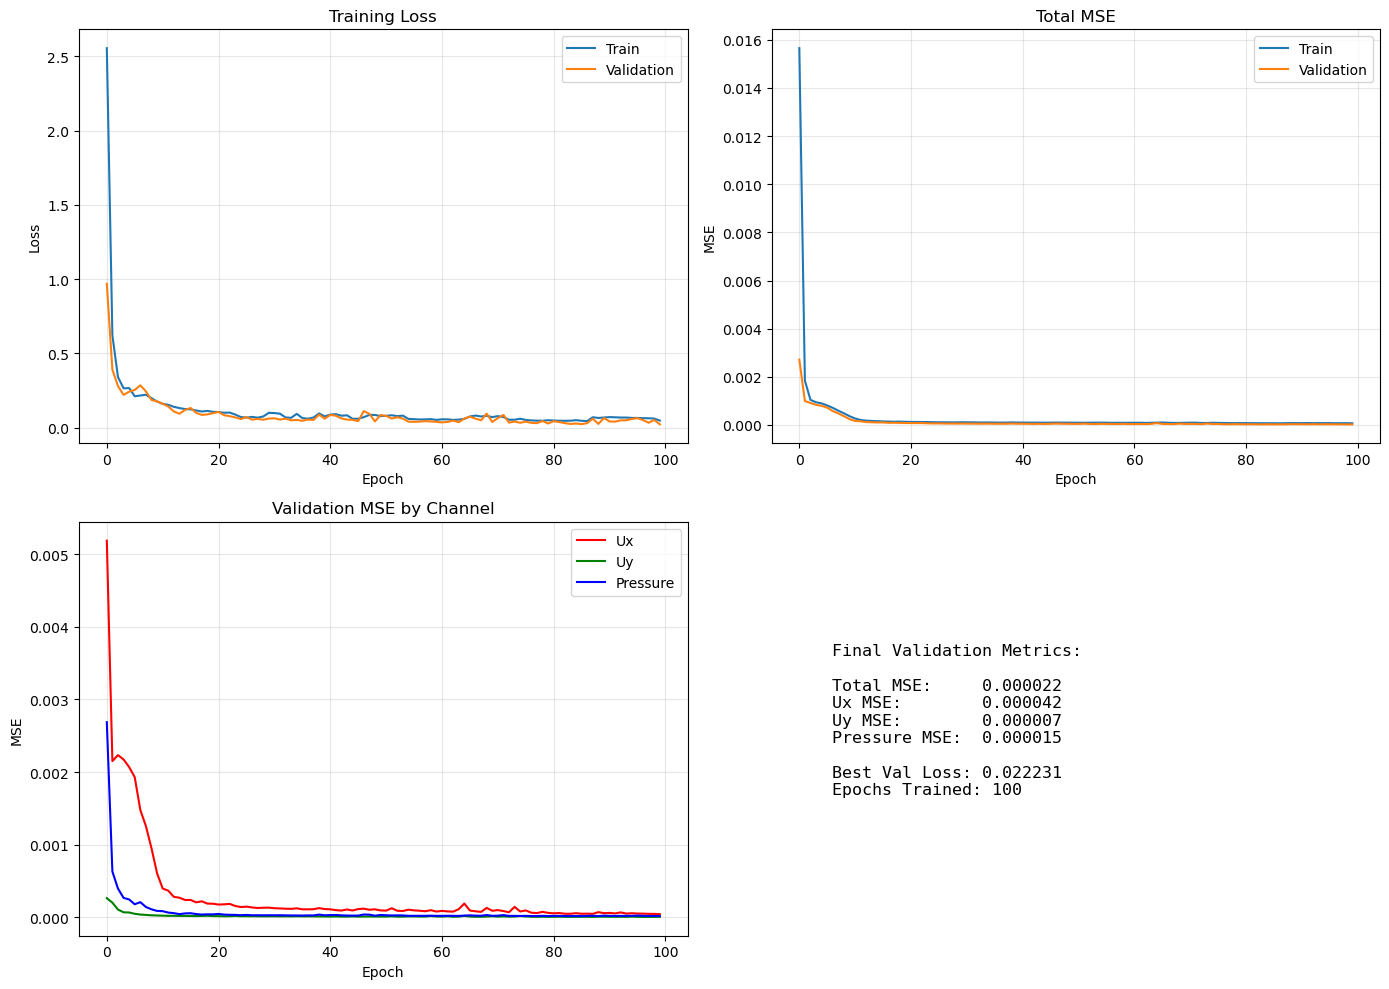

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss curves
axes[0, 0].plot(history['train_loss'], label='Train')
axes[0, 0].plot(history['val_loss'], label='Validation')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Total MSE
axes[0, 1].plot(history['train_mse'], label='Train')
axes[0, 1].plot(history['val_mse'], label='Validation')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MSE')
axes[0, 1].set_title('Total MSE')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Per-channel validation MSE
axes[1, 0].plot(history['val_ux'], label='Ux', color='red')
axes[1, 0].plot(history['val_uy'], label='Uy', color='green')
axes[1, 0].plot(history['val_p'], label='Pressure', color='blue')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('MSE')
axes[1, 0].set_title('Validation MSE by Channel')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Final metrics summary
axes[1, 1].axis('off')
summary_text = f"""Final Validation Metrics:

Total MSE:     {history['val_mse'][-1]:.6f}
Ux MSE:        {history['val_ux'][-1]:.6f}
Uy MSE:        {history['val_uy'][-1]:.6f}
Pressure MSE:  {history['val_p'][-1]:.6f}

Best Val Loss: {best_val_loss:.6f}
Epochs Trained: {len(history['train_loss'])}
"""
axes[1, 1].text(0.1, 0.5, summary_text, fontsize=12, family='monospace',
                verticalalignment='center')

plt.tight_layout()
plt.show()

## Visualize Predictions

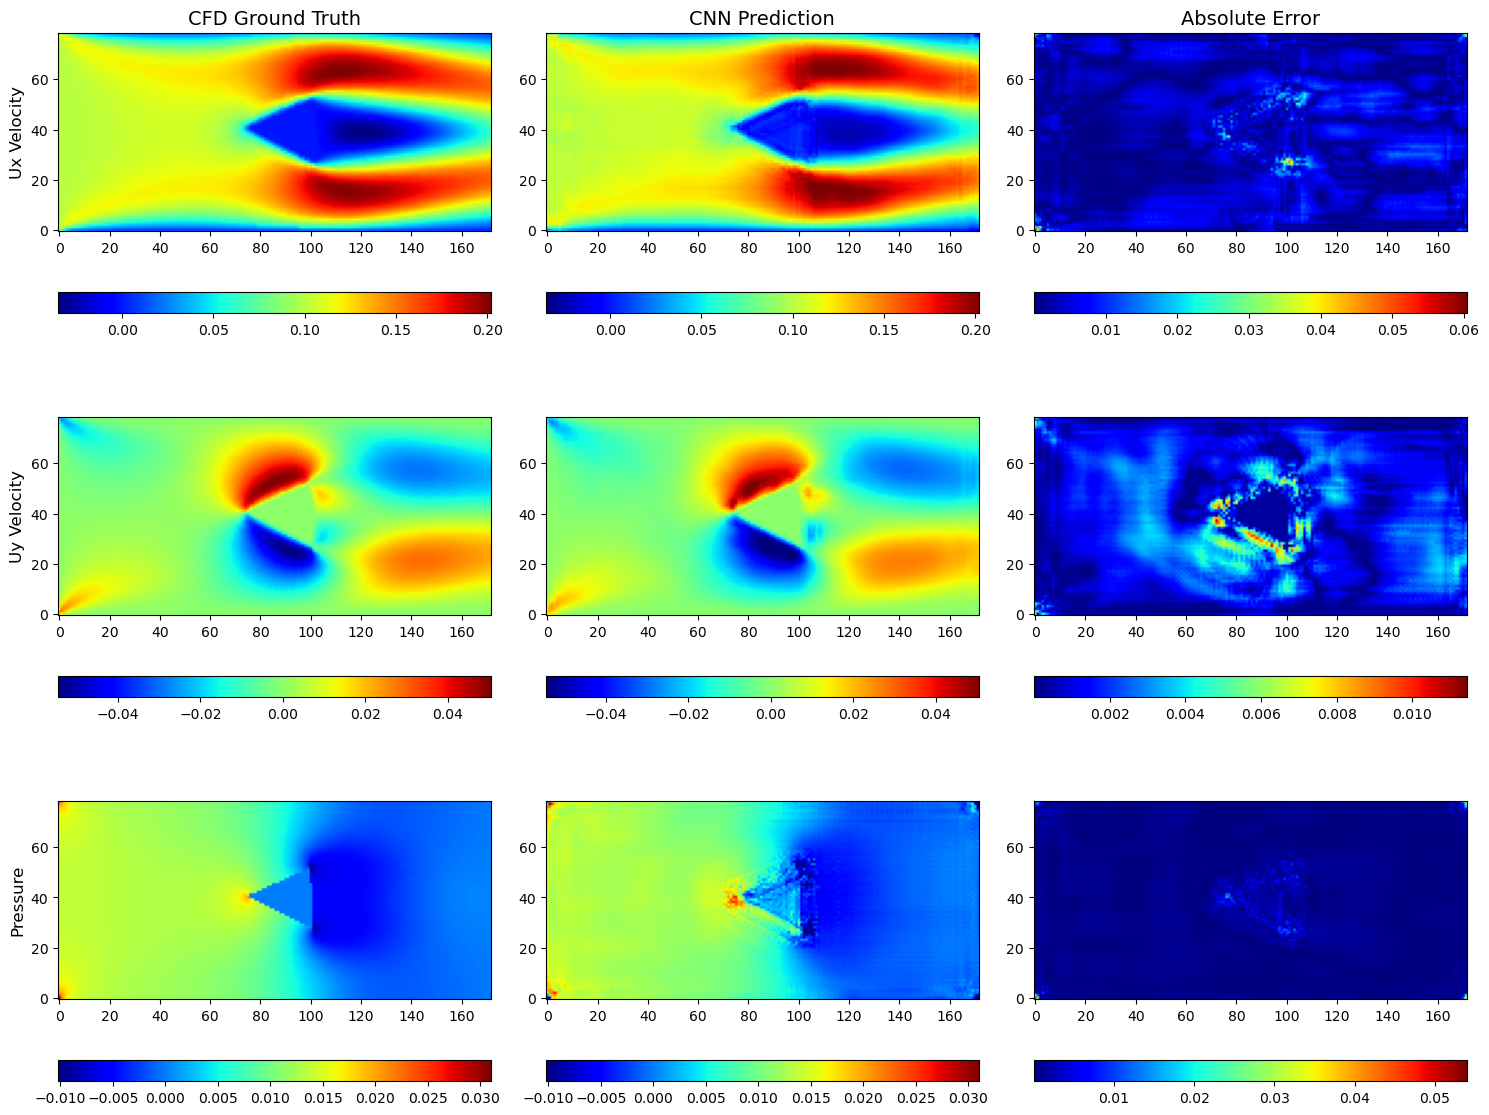


Error Statistics for Sample 0:
  Ux       - Mean: 0.003596, Max: 0.060357
  Uy       - Mean: 0.001549, Max: 0.011433
  Pressure - Mean: 0.000659, Max: 0.053956


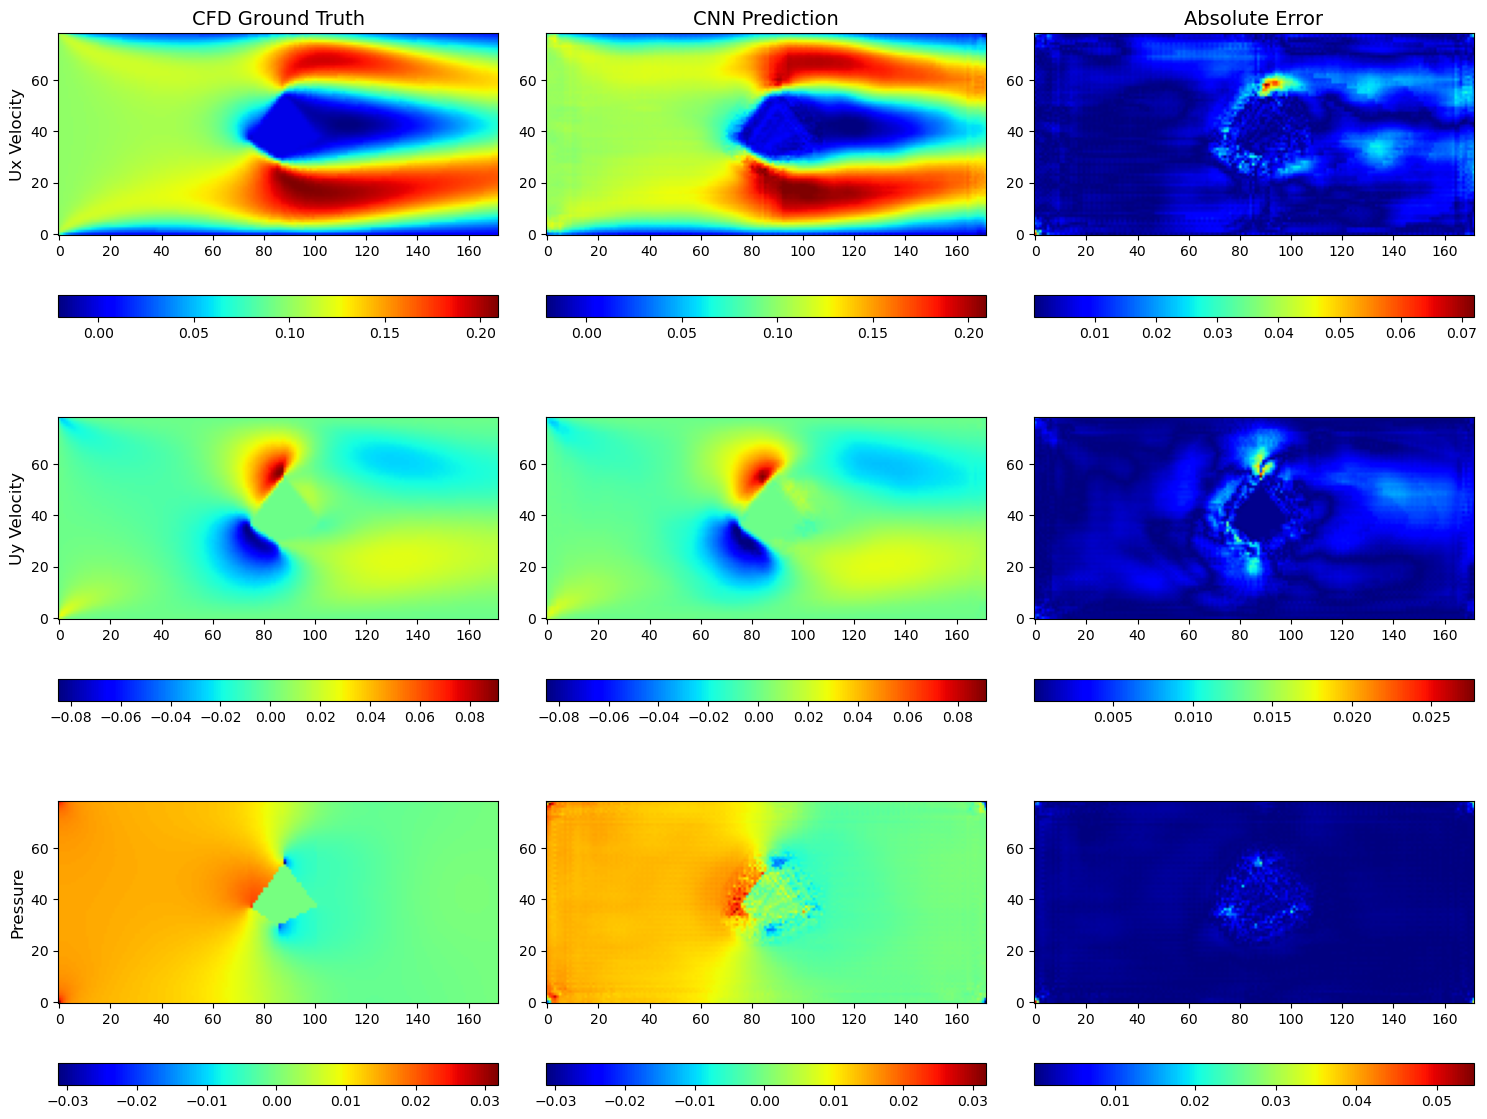


Error Statistics for Sample 1:
  Ux       - Mean: 0.005941, Max: 0.071984
  Uy       - Mean: 0.001727, Max: 0.027681
  Pressure - Mean: 0.000807, Max: 0.054596


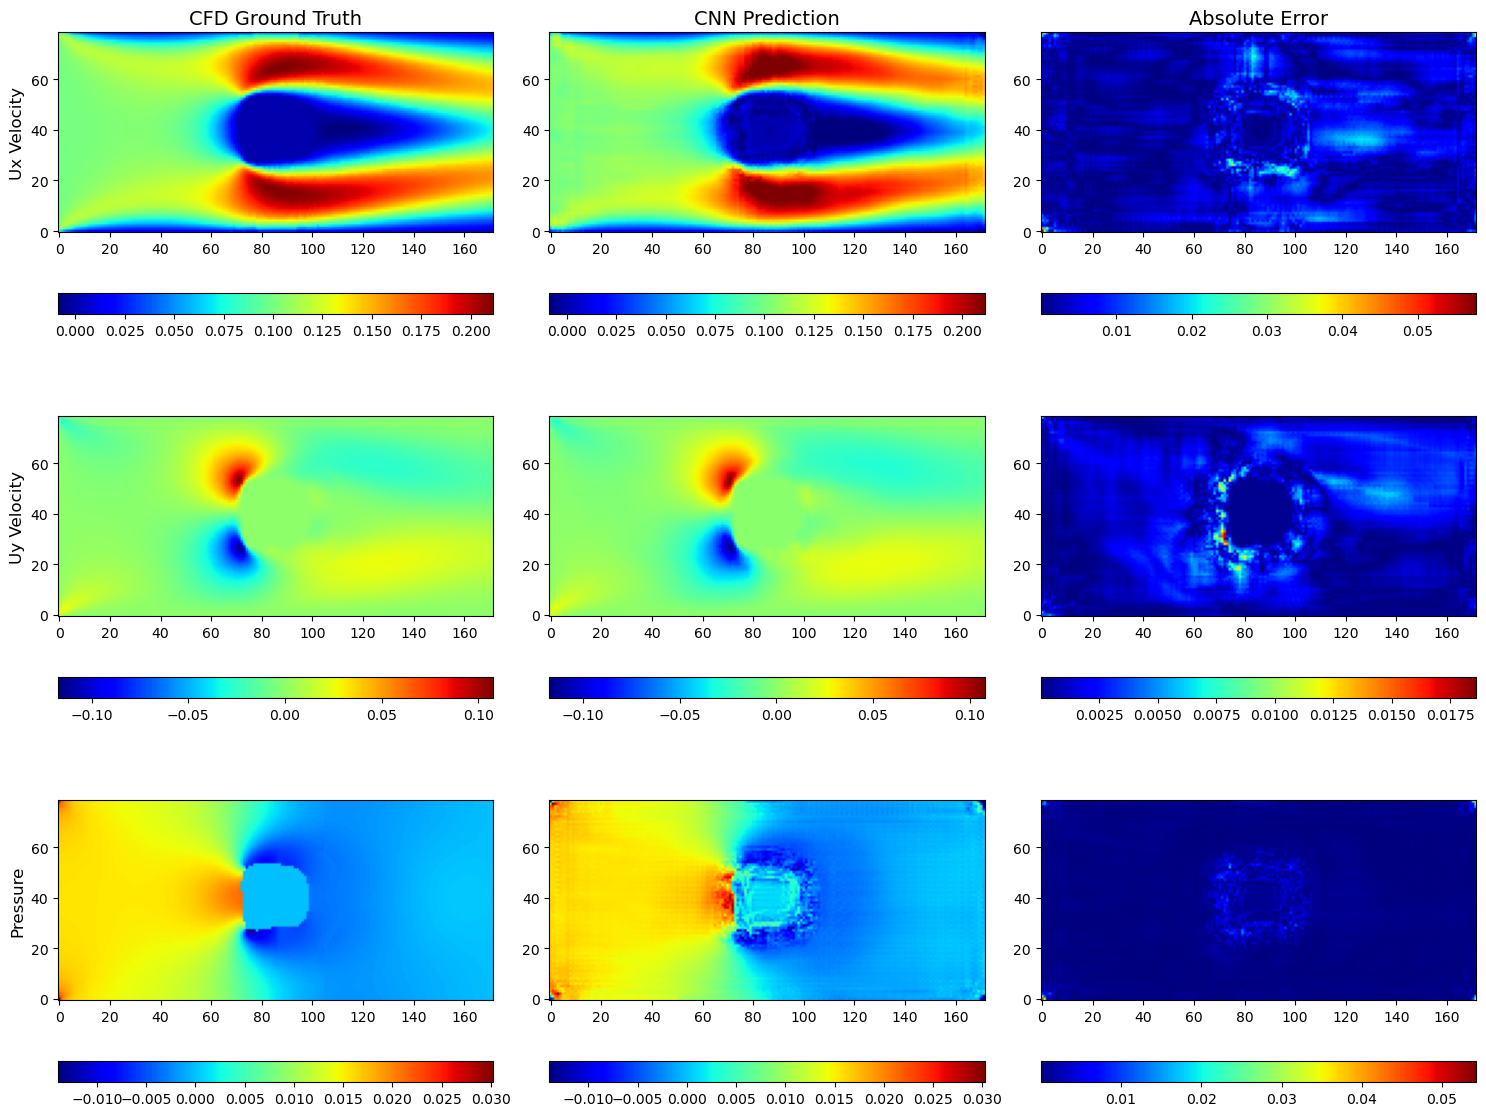


Error Statistics for Sample 2:
  Ux       - Mean: 0.003915, Max: 0.057750
  Uy       - Mean: 0.001537, Max: 0.018620
  Pressure - Mean: 0.000584, Max: 0.054256


In [11]:
def visualize_predictions(model, test_x, test_y, idx=0):
    """Visualize CFD ground truth, CNN prediction, and error"""
    model.eval()
    with torch.no_grad():
        sample_x = test_x[idx:idx+1].to(device)
        prediction = model(sample_x).cpu().numpy()[0]
    
    ground_truth = test_y[idx].numpy()
    error = np.abs(prediction - ground_truth)
    
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    titles = ['Ux Velocity', 'Uy Velocity', 'Pressure']
    
    for i, title in enumerate(titles):
        # Ground truth
        vmin, vmax = ground_truth[i].min(), ground_truth[i].max()
        im0 = axes[i, 0].imshow(ground_truth[i].T, cmap='jet', origin='lower', vmin=vmin, vmax=vmax)
        axes[i, 0].set_ylabel(title, fontsize=12)
        if i == 0:
            axes[i, 0].set_title('CFD Ground Truth', fontsize=14)
        plt.colorbar(im0, ax=axes[i, 0], orientation='horizontal')
        
        # Prediction
        im1 = axes[i, 1].imshow(prediction[i].T, cmap='jet', origin='lower', vmin=vmin, vmax=vmax)
        if i == 0:
            axes[i, 1].set_title('CNN Prediction', fontsize=14)
        plt.colorbar(im1, ax=axes[i, 1], orientation='horizontal')
        
        # Error
        im2 = axes[i, 2].imshow(error[i].T, cmap='jet', origin='lower')
        if i == 0:
            axes[i, 2].set_title('Absolute Error', fontsize=14)
        plt.colorbar(im2, ax=axes[i, 2], orientation='horizontal')
    
    plt.tight_layout()
    plt.show()
    
    # Print error statistics
    print(f"\nError Statistics for Sample {idx}:")
    for i, name in enumerate(['Ux', 'Uy', 'Pressure']):
        print(f"  {name:8s} - Mean: {error[i].mean():.6f}, Max: {error[i].max():.6f}")

# Visualize multiple test samples
for idx in range(min(3, len(test_x))):
    visualize_predictions(model, test_x, test_y, idx=idx)

## Test Set Metrics

In [12]:
# Compute comprehensive test set metrics (matching original DeepCFD software)
# Original metric: sum of squared errors per sample (not standard MSE)
model.eval()

print("Computing predictions on test set...")

# Initialize accumulators
mse_total_sum = 0.0
mse_ux_sum = 0.0
mse_uy_sum = 0.0
mse_p_sum = 0.0
n_samples = 0

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        predictions = model(batch_x)
        
        # Compute sum of squared errors for each channel (matching original implementation)
        # Original: torch.sum((output[:,i,:,:] - target[:,i,:,:]) ** 2)
        mse_ux_sum += float(torch.sum((predictions[:, 0, :, :] - batch_y[:, 0, :, :]) ** 2))
        mse_uy_sum += float(torch.sum((predictions[:, 1, :, :] - batch_y[:, 1, :, :]) ** 2))
        mse_p_sum += float(torch.sum((predictions[:, 2, :, :] - batch_y[:, 2, :, :]) ** 2))
        mse_total_sum += float(torch.sum((predictions - batch_y) ** 2))
        
        n_samples += len(batch_x)

# Divide by number of samples (matching original implementation)
# Original: sum(scope["list"]) / len(scope["dataset"])
mse_ux = mse_ux_sum / n_samples
mse_uy = mse_uy_sum / n_samples
mse_p = mse_p_sum / n_samples
mse_total = mse_total_sum / n_samples
mse_sum = mse_ux + mse_uy + mse_p  # Sum of individual channel MSEs

print("\n" + "="*60)
print("TEST SET METRICS (Original DeepCFD Format)")
print("="*60)
print(f"\nPer-Channel MSE (sum of squared errors / n_samples):")
print(f"  Ux MSE:  {mse_ux:.6e}")
print(f"  Uy MSE:  {mse_uy:.6e}")
print(f"  p  MSE:  {mse_p:.6e}")
print(f"\nTotal MSE (all channels):  {mse_total:.6e}")
print("="*60)

Computing predictions on test set...

TEST SET METRICS (Original DeepCFD Format)

Per-Channel MSE (sum of squared errors / n_samples):
  Ux MSE:  5.758338e-01
  Uy MSE:  9.999717e-02
  p  MSE:  2.041319e-01

Total MSE (all channels):  8.799628e-01


## Save Model

In [ ]:
# Save model with metadata
model_state = {
    'state_dict': model.state_dict(),
    'input_shape': (1, 3, nx, ny),
    'filters': [8, 16, 32, 32],
    'kernel_size': 5,
    'best_val_loss': best_val_loss,
    'history': history
}

torch.save(model_state, 'deepcfd_model.pt')
print("Model saved as 'deepcfd_model.pt'")

Model saved as 'deepcfd_model.pt'


In [ ]:
checkpoint = torch.load('deepcfd_model.pt')
model.load_state_dict(checkpoint['state_dict'])

<All keys matched successfully>